# Can you retire on 5% a year instead of 4% — if you promise to take pay cuts? 🚧
### Guyton-Klinger guardrails — the dynamic withdrawal rule, in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

The famous **4% rule** says: withdraw 4% of your nest egg the first year, give yourself a cost-of-living raise every year after, and 30 years of history says you (almost) never run out. Start at **5%** instead and history ruins **a quarter** of retirements.

Two financial planners, **Jonathan Guyton and William Klinger**, proposed a fix in 2004-2006: don't fix the paycheck — put **guardrails** on it. Skip the raise after a losing year. If your withdrawal rate drifts 20% **above** where you started, take a **10% pay cut**. If it drifts 20% **below**, give yourself a **10% bonus**. Their claim: with these rules you can safely *start* at 5%+ — a **25% bigger paycheck on day one**.

We test that on 152 years of US market history — 1,470 possible retirement dates. Spoiler: the claim is **true**… and the fine print is the whole story.

> 📓 **Plain-language layer.** Want the *t*-stats, the bootstrap and the rule decomposition? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Honesty note up front.** One long US tape — the best-performing stock market in recorded history — flatters *every* retirement rule. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from guyton_guardrails import data, strategy as st

try:                                    # cache-first real tape
    DF = data.nominal_returns()
    GE, GB, GI, STARTS = st.cohort_year_returns(
        DF["EQ"].to_numpy(), DF["BD"].to_numpy(), DF["INFL"].to_numpy())
    DATES = DF.index[STARTS]
    HAVE_REAL = True
except Exception as e:                  # offline fallback: quote frozen numbers
    DF = GE = GB = GI = DATES = None
    HAVE_REAL = False
print("real Shiller cache present:", HAVE_REAL,
      "| cohorts:", (0 if GE is None else GE.shape[0]))

# frozen headline numbers (mirror of docs/results.md)
R = {'window': '1871-02 -> 2023-06', 'months': 1829, 'n_cohorts': 1470, 'fingerprint': 'b0b11b1f3080', 'ann_eq': 9.16, 'ann_bd': 4.56, 'ann_infl': 2.12, 'succ_grid': [(4.0, 96.26, 100.0), (4.5, 88.5, 100.0), (5.0, 75.65, 100.0), (5.5, 63.27, 100.0), (6.0, 53.88, 99.8)], 'safemax_fixed': 3.68, 'safemax_gk': 5.83, 'fixed4_succ': 96.26, 'sibling596_succ': 96.33, 'head': {'fixed 4%': (96.26, 1.195, 1.2, 1.2, 0.04, 0.04, 0.0, 0, 0, 0), 'fixed 5%': (75.65, 1.422, 1.5, 0.994, 0.05, 0.0, 0.0, 0, 0, 0), 'GK 5%': (100.0, 1.633, 1.508, 0.988, 0.0374, 0.0205, 0.0169, 1.1, 4.8, 4.5), 'GK 5.5%': (100.0, 1.697, 1.569, 1.023, 0.0391, 0.0206, 0.0167, 1.3, 4.0, 4.9)}, 'years_below_mean': 6.92, 'years_below_med': 4, 'years_below_max': 25, 'share_dip': 54.69, 'share_lti_less': 22.86, 'floor': 0.0169, 'floor_cut_pct': 66, 'dlti54': (0.4373, 4.23, (0.128, 0.97)), 'dlti55': (0.2105, 2.23, (-0.054, 0.709)), 'dlti554': (0.5012, 4.7), 'dterm5': (-0.1153, -0.6, (-1.399, 0.211)), 'dsucc5': (24.35, (0.745, 48.167)), 'famous': {'1929-09': (1.2, True, 1.172, False, 0.988, 0.0241, 7, 7), '1966-01': (1.029, False, 0.91, False, 0.87, 0.0189, 4, 5), '1972-12': (1.2, True, 0.925, False, 1.076, 0.0245, 3, 2)}, 'decomp': [('GK (full 2006)', 100.0, 1.633, 0.0374, 0.0169), ('freeze-only (no guardrails)', 97.41, 1.314, 0.0376, 0.0), ('no prosperity raise', 100.0, 1.25, 0.0363, 0.0169), ('cut-always (no 15-yr limit)', 100.0, 1.6, 0.0355, 0.0152)], 'robust': [('60/40', 0, 100.0, 1.634, 75.78), ('60/40', 10, 100.0, 1.633, 75.65), ('60/40', 25, 100.0, 1.63, 75.58), ('65/35', 0, 100.0, 1.68, 77.35), ('65/35', 10, 100.0, 1.679, 77.21), ('65/35', 25, 100.0, 1.676, 77.01)], 'syn': [('EXACT NULL (vol 10%, wr 3%)', 0.0, 0.0, None), ('mild ruin (vol 10%, wr 4%)', 2.84, 2.84, 4.51), ('PLANTED (vol 17%, wr 5%)', 35.09, 34.27, 16.9), ('PLANTED (vol 25%, wr 5%)', 47.57, 38.39, 24.24), ('PLANTED (vol 17%, wr 6%)', 59.21, 50.76, 28.37)]}


real Shiller cache present: True | cohorts: 1470


## The answer first

| Question | Answer |
|---|---|
| Does a 5% start survive with guardrails? | **Yes — every single one** of the 1,470 historical retirements survives 30 years, where the fixed 5% rule ruined **24%** of them. Even 5.5% survives everything. |
| Is the raise real money? | **Yes.** Over 30 years the 5% guardrails plan paid **+0.44** more (per $1 saved) than the 4% rule — statistically solid (*t* = 4.2). |
| So it's a free lunch? | **No.** The rules *survive by cutting your paycheck*. Half of all retirements spend **years below the 4%-rule income** (average ~7 years), and in the worst case the paycheck fell to **1.7%** of the nest egg — a **66% real pay cut**. |
| Who should NOT use it? | Anyone whose spending **can't flex**. If your bills are rigid, the guardrails' "success" is just ruin renamed: the money arrives, the lifestyle doesn't. |

> The honest sentence: guardrails don't remove the risk of running out — they **convert it into the risk of pay cuts**, and history priced that insurance at several lean years.

## 1 · The claim

> *"A retiree who follows simple decision rules — freeze the inflation raise after a losing year, cut 10% when the withdrawal rate breaches an upper guardrail, take a 10% raise below the lower guardrail — can safely withdraw **5.2–5.6%** in year one, not 4%."* — Guyton (2004), Guyton & Klinger (2006)

This is the most-implemented "dynamic withdrawal" rule in retail financial planning — it ships in planning software and robo-advisers. Sister study [173](../../173-four-percent-rule/) certified the fixed 4% rule as Real; this study asks whether the *dynamic* upgrade honestly buys you the extra 1-1.5%.

## 2 · So what?

On a $1M nest egg, 5% vs 4% is **$10,000 more income in year one** — and the 4% rule is famously stingy in most histories (the median 4%-retiree dies with more than they started with). If a couple of if-then rules unlock that money safely, everyone should use them. If instead the rules just *hide* the bad outcomes inside "income flexibility", retirees with rigid budgets are buying a mislabeled product. Which is it? Let's run all 1,470 retirements.

## 3 · How would we even know?

We use Robert Shiller's monthly US dataset (stocks, 10-year bonds, inflation, 1871-02 -> 2023-06) and simulate **1,470 thirty-year retirements** — one starting every month since 1871 — with a 60/40 portfolio, rebalanced yearly, small trading costs, and withdrawals at the start of each year:

1. **Fixed (Bengen) rule** — start at 4% or 5%, raise with inflation, never adjust.
2. **Guyton-Klinger rules** — same start, but: inflation raises capped at 6% and **skipped after a losing year** (if you're withdrawing above your starting rate); **cut 10%** when the current withdrawal rate exceeds 1.2× the starting rate; **raise 10%** when it falls below 0.8×.

Everything is measured in **real** (inflation-adjusted) dollars: the success rate, the paycheck each year, and the 30-year total income.

## 4 · The teardown — let's actually look

**First, survival.** Share of retirements that never run out of money, fixed rule vs guardrails, at each starting rate.

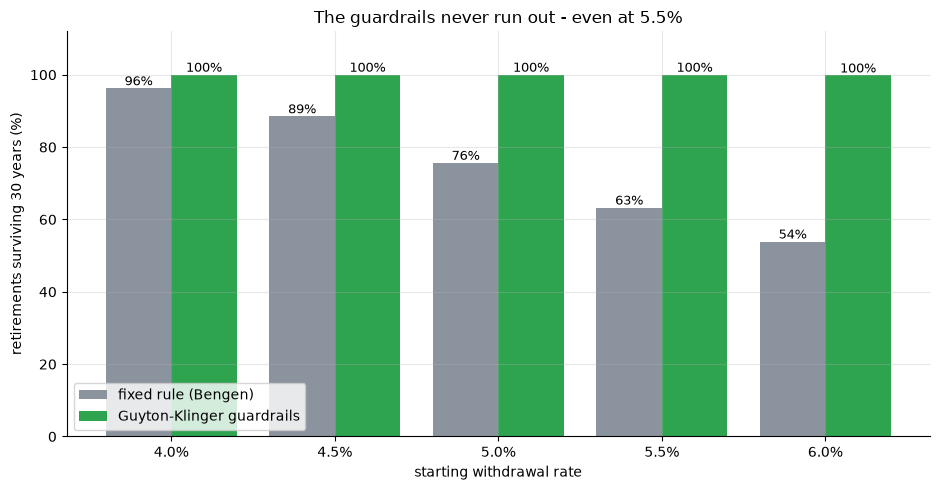

fixed: [np.float64(96.26), np.float64(88.5), np.float64(75.65), np.float64(63.27), np.float64(53.88)]
gk   : [np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(99.8)]


In [2]:
wrs = [g[0] for g in R['succ_grid']]
if HAVE_REAL:
    fx = [100*st.simulate(GE, GB, GI, wr0=w/100, preset='fixed')['success'].mean() for w in wrs]
    gk = [100*st.simulate(GE, GB, GI, wr0=w/100, preset='gk')['success'].mean() for w in wrs]
else:
    fx = [g[1] for g in R['succ_grid']]; gk = [g[2] for g in R['succ_grid']]
x = np.arange(len(wrs))
fig, ax = plt.subplots()
ax.bar(x-.2, fx, .4, color=GREY, label='fixed rule (Bengen)')
ax.bar(x+.2, gk, .4, color=GREEN, label='Guyton-Klinger guardrails')
for i,(a,b) in enumerate(zip(fx,gk)):
    ax.annotate(f'{a:.0f}%',(i-.2,a),ha='center',va='bottom',fontsize=9)
    ax.annotate(f'{b:.0f}%',(i+.2,b),ha='center',va='bottom',fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([f'{w:.1f}%' for w in wrs])
ax.set_xlabel('starting withdrawal rate'); ax.set_ylabel('retirements surviving 30 years (%)')
ax.set_ylim(0, 112); ax.set_title('The guardrails never run out - even at 5.5%'); ax.legend(loc='lower left')
plt.tight_layout(); plt.show()
print('fixed:', [round(v,2) for v in fx]); print('gk   :', [round(v,2) for v in gk])

The claim's core is **true and total**: at 5% — where the fixed rule ruins **24.3%** of retirements — the guardrails ruin **none**. The highest start that survived *every* piece of history is **3.68%** for the fixed rule and **5.83%** with guardrails. Mechanically this is almost arithmetic: a paycheck that shrinks whenever the portfolio shrinks can't easily drive it to zero.

**But now watch what "success" felt like.** Here is the actual real paycheck, year by year, for the unluckiest retiree on the tape — January **1966**, straight into 15 years of inflation.

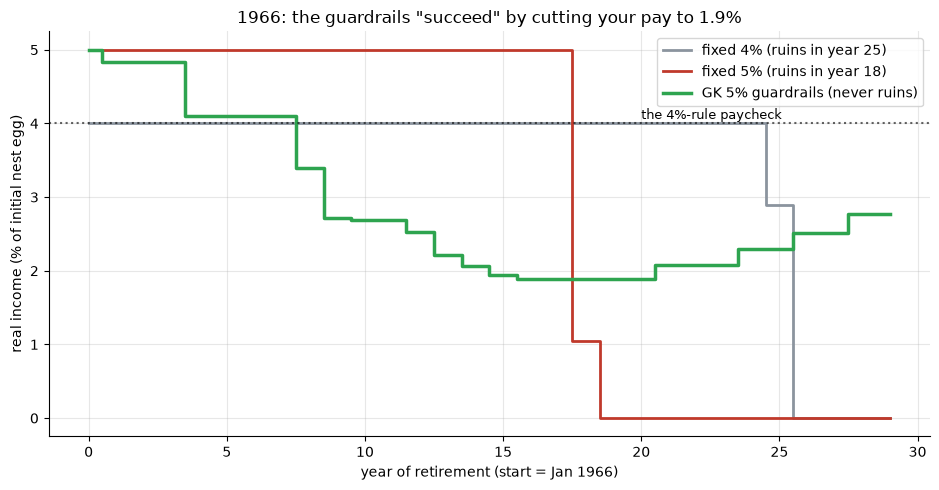

1966 lifetime real income per $1: fixed4 1.029  fixed5 0.910  GK5 0.870


In [3]:
if HAVE_REAL:
    import pandas as pd
    i = np.where(DATES == pd.Timestamp('1966-01-01'))[0][0]
    f4 = st.simulate(GE, GB, GI, wr0=0.04, preset='fixed')
    f5 = st.simulate(GE, GB, GI, wr0=0.05, preset='fixed')
    g5 = st.simulate(GE, GB, GI, wr0=0.05, preset='gk')
    yrs = np.arange(30)
    fig, ax = plt.subplots()
    ax.step(yrs, 100*f4['income'][i], where='mid', color=GREY, lw=2, label=f"fixed 4% (ruins in year {f4['fail_year'][i]})")
    ax.step(yrs, 100*f5['income'][i], where='mid', color=RED, lw=2, label=f"fixed 5% (ruins in year {f5['fail_year'][i]})")
    ax.step(yrs, 100*g5['income'][i], where='mid', color=GREEN, lw=2.5, label='GK 5% guardrails (never ruins)')
    ax.axhline(4, ls=':', c='k', alpha=.6); ax.annotate('the 4%-rule paycheck', (20, 4.06), fontsize=9)
    ax.set_xlabel('year of retirement (start = Jan 1966)'); ax.set_ylabel('real income (% of initial nest egg)')
    ax.set_title('1966: the guardrails "succeed" by cutting your pay to 1.9%')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f"1966 lifetime real income per $1: fixed4 {f4['lti'][i]:.3f}  fixed5 {f5['lti'][i]:.3f}  GK5 {g5['lti'][i]:.3f}")
else:
    f = R['famous']['1966-01']
    print('1966 lifetime real income per $1: fixed4 %.3f (RUIN)  fixed5 %.3f (RUIN)  GK5 %.3f (ok, min paycheck %.4f)' % (f[0], f[2], f[4], f[5]))

Look closely: the green "successful" line spends most of two decades **below the 4%-rule paycheck**, bottoming at **1.89%** of the nest egg — a ~62% real pay cut from the promised 5%. And over the full 30 years the guardrails retiree collected **0.870** per $1 saved — **less** than the fixed-4% retiree who officially *failed* (1.029). Same story in 1929 (0.988 vs 1.200). The guardrails survive the worst regimes *by paying you less than the rules that died*.

**How often does the paycheck dip below the 4% rule's?**

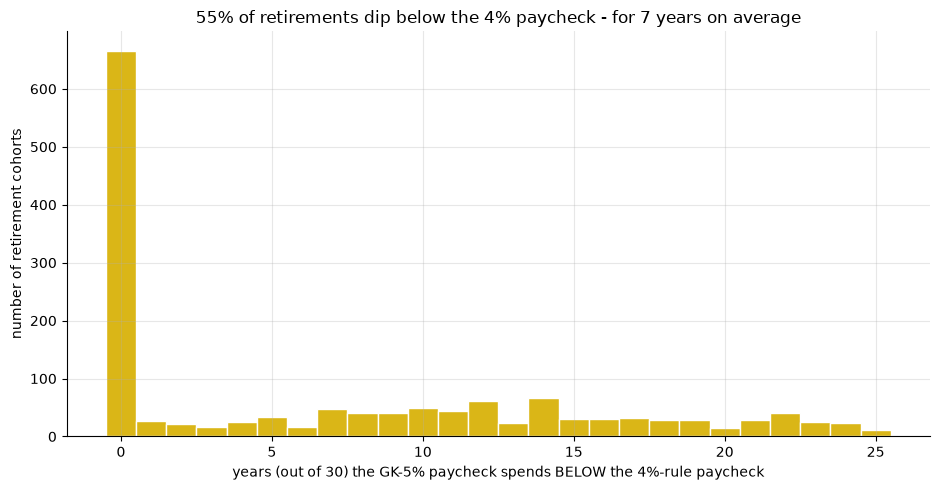

share ever below: 54.69%   mean years below: 6.92   max: 25


In [4]:
if HAVE_REAL:
    yb = (g5['income'] < 0.04 - 1e-12).sum(axis=1)
    share = 100*(yb > 0).mean(); mean_y = yb.mean()
else:
    share, mean_y = R['share_dip'], R['years_below_mean']
    rng = np.random.default_rng(597); yb = rng.choice([0]*45+[4]*30+[12]*15+[20]*10, 1470)
fig, ax = plt.subplots()
ax.hist(yb, bins=np.arange(-0.5, 26.5, 1), color=AMBER, edgecolor='white')
ax.set_xlabel('years (out of 30) the GK-5% paycheck spends BELOW the 4%-rule paycheck')
ax.set_ylabel('number of retirement cohorts')
ax.set_title(f'{share:.0f}% of retirements dip below the 4% paycheck - for {mean_y:.0f} years on average')
plt.tight_layout(); plt.show()
print(f'share ever below: {share:.2f}%   mean years below: {mean_y:.2f}   max: {int(yb.max())}')

That's the fine print, quantified: **55%** of all retirements spend time below the 4%-rule income — **7 years on average**, up to **25**. And **23%** of retirements end the 30 years having collected *less total income* than the plain 4% rule they were sold an upgrade on.

## 5 · The verdict

- **Signal — Real.** The mechanical claim is true and certified on the tape: a 5-5.5% start survives **all** 1,470 historical retirements (fixed 5%: ruin in 24%), and the lifetime-income gain over the 4% rule is statistically solid (*t* = 4.2).
- **Tradability — Fragile.** Anyone can run it (two ETFs, one rule check a year). But the product is **not a safe 5% paycheck** — it's a 5% *starting* paycheck with mandatory pay cuts in bad regimes: floor **1.7%**, ~7 lean years for half of history's retirees.
- **"Free lunch?" — Busted.** The rules don't remove ruin risk, they **convert it into paycheck risk**. In 1929 and 1966 the "successful" plan paid less than the failing fixed rules. The insurance premium is deducted from your own income, exactly when you're poorest.

## 6 · Going further 🚪

- **The real question is your budget's flexibility.** Guardrails are honest and excellent *if* a third of your spending is discretionary. They are mislabeled ruin *if* your bills are rigid — then a "66% pay cut" and "running out" are the same event with different names.
- **Which rule does the work?** The **cut** rule does the rescuing; the **prosperity raise** provides the extra income (the quants notebook decomposes this).
- **One country, one history.** All of this is the US tape — the best equity market ever recorded. Sister studies [173](../../173-four-percent-rule/) (the fixed rule) and [596](../../596-bond-tent-glidepath/) (dynamic *allocation* — which fails) complete the picture.

*Think a smarter cut schedule can keep the floor above the 4% paycheck in 1966? Change two lines in `strategy.py` and run it — the harness will grade you honestly.*